Q1_part1_1

In [1]:
# Import required libraries
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


 Image count per class per domain:


,art_painting,cartoon,photo,sketch
dog,379,389,189,772
elephant,255,457,202,740
giraffe,285,346,182,753
guitar,184,135,186,608
horse,201,324,199,816
house,295,288,280,80
person,449,405,432,160


<Figure size 1200x600 with 0 Axes>

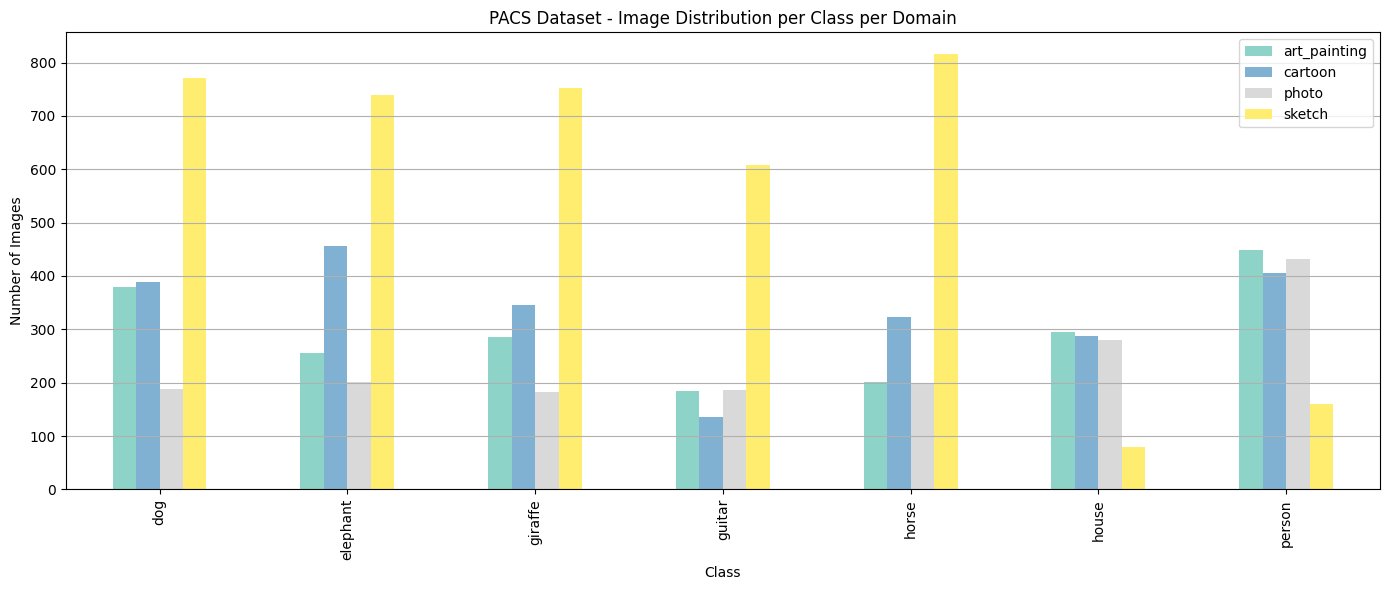

In [2]:
# load dataset
dataset_path = ''

# Explore directory structure
for root, dirs, files in os.walk(dataset_path):
    print(f"\n {root}")
    for d in dirs:
        print("  ", d)
    for f in files[:5]:  # show only first 5 files
        print("  ", f)

# Summarize the dataset
# The dataset is expected to have the structure:
# PACS/
# ├── art_painting/
# ├── cartoon/
# ├── photo/
# └── sketch/
# Each folder contains subfolders for each class (e.g., dog, elephant, etc.)

domains = ['art_painting', 'cartoon', 'photo', 'sketch']
summary = {}

for domain in domains:
    domain_path = os.path.join(dataset_path, 'kfold', domain)
    classes = os.listdir(domain_path)
    summary[domain] = {}

    for cls in classes:
        class_path = os.path.join(domain_path, cls)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            summary[domain][cls] = num_images

# Convert summary to DataFrame
df_summary = pd.DataFrame(summary).fillna(0).astype(int)
print("\n Image count per class per domain:")
display(df_summary)

# Plot summary
plt.figure(figsize=(12, 6))
df_summary.plot(kind='bar', figsize=(14, 6), colormap='Set3')
plt.title("PACS Dataset - Image Distribution per Class per Domain")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


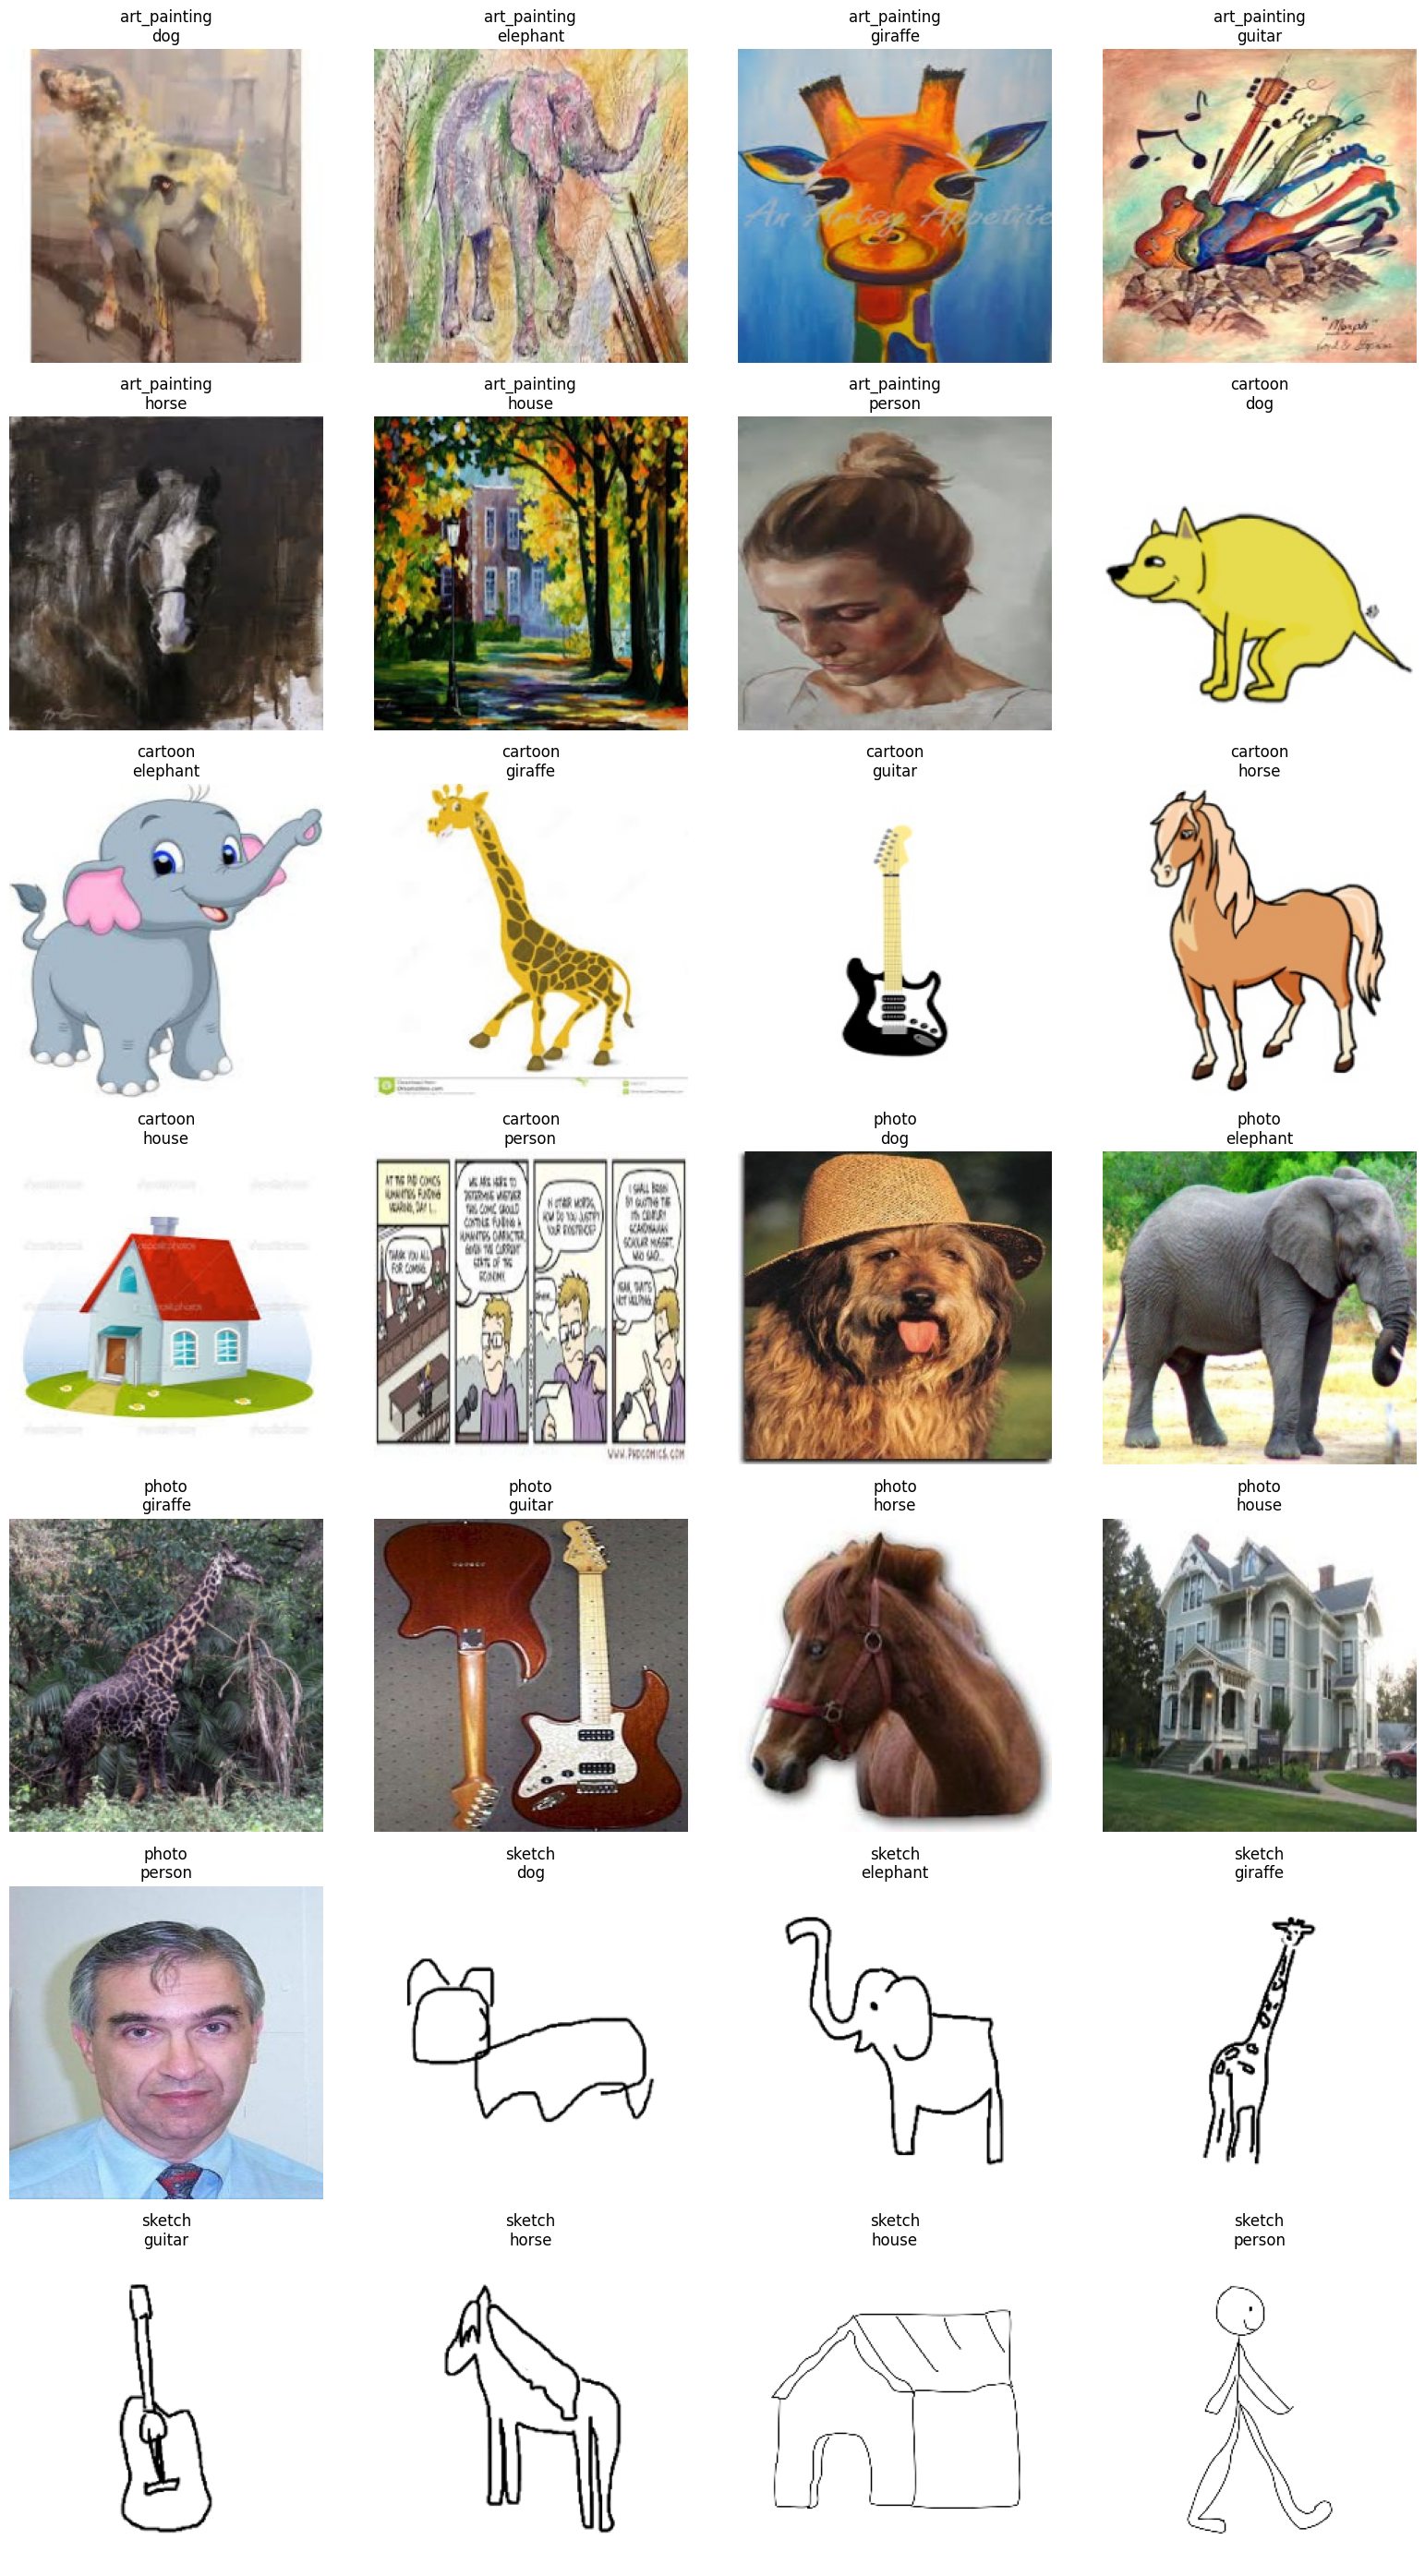

In [3]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Fixed domain root
domain_root = os.path.join(dataset_path, 'kfold')
domains = ['art_painting', 'cartoon', 'photo', 'sketch']

# First, collect all (domain, subclass, image) triplets
images_info = []

for domain in domains:
    domain_path = os.path.join(domain_root, domain)
    class_names = os.listdir(domain_path)

    for class_name in class_names:
        class_path = os.path.join(domain_path, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        if not image_files:
            continue

        chosen_image = random.choice(image_files)
        image_path = os.path.join(class_path, chosen_image)

        images_info.append((domain, class_name, image_path))

# Plot all images
plt.figure(figsize=(16, len(images_info)))

for idx, (domain, class_name, image_path) in enumerate(images_info):
    img = Image.open(image_path)
    plt.subplot(len(images_info) // len(domains), len(domains), idx + 1)
    plt.imshow(img)
    plt.title(f"{domain}\n{class_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()


Part2_Subpart1_1

In [4]:
# Preprocessing for ResNet18
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)
model.eval()
model = model.cuda() if torch.cuda.is_available() else model


C:\Users\Lenovo\AppData\Roaming\Python\Python39\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python39\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths and domains
data_root = "./kfold"
domains = ['art_painting', 'cartoon', 'photo', 'sketch']
num_classes = 7
epochs = 1
batch_size = 64

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load pretrained ResNet18
resnet = models.resnet18(weights="IMAGENET1K_V1")
for param in resnet.parameters():
    param.requires_grad = False  # Freeze all layers

# Replace the classifier with an MLP
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet = resnet.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

# To store accuracy results
results = {}

# Evaluate each domain
for domain in domains:
    print(f"\n Training and Evaluating on domain: {domain}")

    # Load dataset
    domain_path = os.path.join(data_root, domain)
    dataset = datasets.ImageFolder(domain_path, transform=transform)

    # Split into 80% train, 20% test
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # Train only the classifier head
    for epoch in range(epochs):
        resnet.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = resnet(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1} loss: {running_loss/len(train_loader):.4f}")

    # Evaluation
    resnet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    results[domain] = acc
    print(f" {domain} accuracy: {acc:.2f}%")

# Final summary
print("\n Final Accuracy Summary:")
for domain, acc in results.items():
    print(f"{domain}: {acc:.2f}%")


 Training and Evaluating on domain: art_painting


Epoch 1/1: 100%|██████████| 26/26 [00:05<00:00,  4.85it/s]


Epoch 1 loss: 1.5586
 art_painting accuracy: 67.56%

 Training and Evaluating on domain: cartoon


Epoch 1/1: 100%|██████████| 30/30 [00:05<00:00,  5.93it/s]


Epoch 1 loss: 1.1661
 cartoon accuracy: 80.17%

 Training and Evaluating on domain: photo


Epoch 1/1: 100%|██████████| 21/21 [00:03<00:00,  5.74it/s]


Epoch 1 loss: 0.4723
 photo accuracy: 96.71%

 Training and Evaluating on domain: sketch


Epoch 1/1: 100%|██████████| 50/50 [00:07<00:00,  6.35it/s]


Epoch 1 loss: 1.0370
 sketch accuracy: 62.72%

 Final Accuracy Summary:
art_painting: 67.56%
cartoon: 80.17%
photo: 96.71%
sketch: 62.72%


Part1_SubPart2_2

In [6]:
torch.save(resnet.state_dict(), "resnet18_dann_1.pth")

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_root = "./kfold"
domains = ['art_painting', 'cartoon', 'photo', 'sketch']
num_classes = 7
epochs = 4
batch_size = 64

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def load_data(domain, split=0.8):
    path = os.path.join(data_root, domain)
    dataset = datasets.ImageFolder(path, transform=transform)
    train_size = int(split * len(dataset))
    test_size = len(dataset) - train_size
    return random_split(dataset, [train_size, test_size])

def evaluate(model, dataloader):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

# Store results like: {'photo': {'art_painting': acc, ...}}
results = {}

for train_domain in domains:
    print(f"\n Fine-tuning on {train_domain} (for {epochs} epochs)")

    # Load model and unfreeze everything
    model = models.resnet18(weights="IMAGENET1K_V1")

    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    # Load training domain data
    train_set, _ = load_data(train_domain)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

    # Fine-tune
    model.train()
    for epoch in range(epochs):
        running_loss = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} loss: {running_loss/len(train_loader):.4f}")

    # Evaluate on other domains
    results[train_domain] = {}
    for test_domain in domains:
        # if test_domain == train_domain:
        #     continue
        _, test_set = load_data(test_domain)
        test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
        acc = evaluate(model, test_loader)
        results[train_domain][test_domain] = acc
        print(f" Tested on {test_domain} → Accuracy: {acc:.2f}%")

# Show final summary
print("\n Final Generalization Results:")
for train_domain in results:
    print(f"\nTrained on {train_domain}:")
    for test_domain, acc in results[train_domain].items():
        print(f"→ {test_domain}: {acc:.2f}%")



 Fine-tuning on art_painting (for 4 epochs)


Epoch 1: 100%|██████████| 26/26 [00:06<00:00,  3.81it/s]


Epoch 1 loss: 0.6401


Epoch 2: 100%|██████████| 26/26 [00:06<00:00,  3.92it/s]


Epoch 2 loss: 0.2064


...

Epoch 2 loss: 0.1644


Epoch 3: 100%|██████████| 50/50 [00:12<00:00,  4.07it/s]


Epoch 3 loss: 0.1104


Epoch 4: 100%|██████████| 50/50 [00:12<00:00,  4.08it/s]


Epoch 4 loss: 0.1447
 Tested on art_painting → Accuracy: 12.93%
 Tested on cartoon → Accuracy: 18.55%
 Tested on photo → Accuracy: 17.37%
 Tested on sketch → Accuracy: 87.79%

 Final Generalization Results:

Trained on art_painting:
→ art_painting: 96.10%
→ cartoon: 53.30%
→ photo: 79.94%
→ sketch: 45.17%

Trained on cartoon:
→ art_painting: 43.66%
→ cartoon: 95.52%
→ photo: 73.65%
→ sketch: 49.75%

Trained on photo:
→ art_painting: 40.73%
→ cartoon: 12.37%
→ photo: 97.31%
→ sketch: 15.78%

Trained on sketch:
→ art_painting: 12.93%
→ cartoon: 18.55%
→ photo: 17.37%
→ sketch: 87.79%


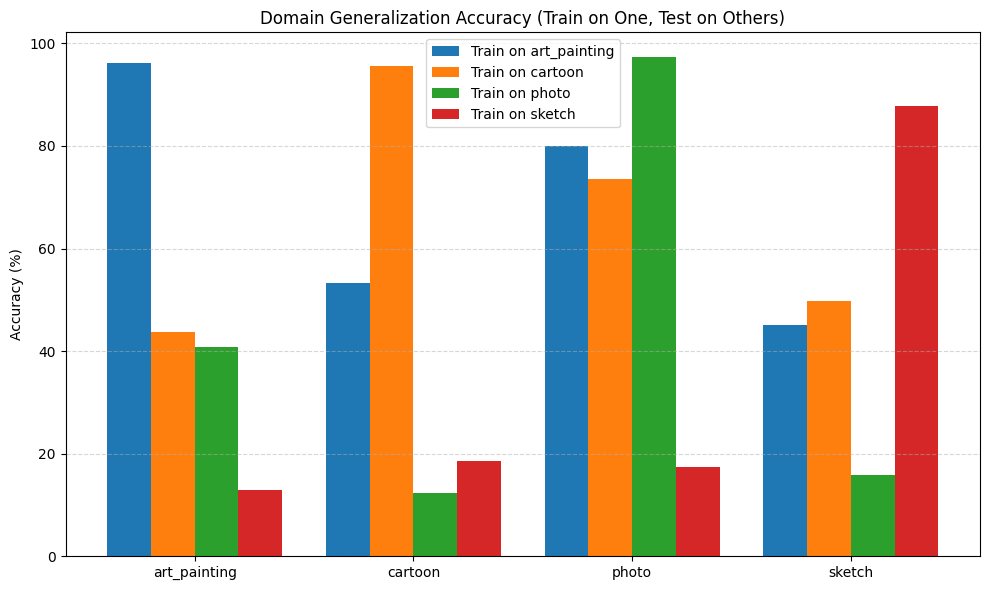

In [8]:
import matplotlib.pyplot as plt
import torch
# needed for torch.arange()

# Extract unique domains
all_domains = sorted(results.keys())

# Fixed x-axis (exclude the train domain dynamically per group)
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))

# Use consistent test domains
test_domain_set = sorted(set(all_domains))

x = torch.arange(len(test_domain_set))  # 4 test domains total

# Plot
for idx, train_domain in enumerate(all_domains):
    accs = []
    xticks = []
    for test_domain in test_domain_set:
        accs.append(results[train_domain][test_domain])
        xticks.append(test_domain)

    bar_x = x + idx * width
    ax.bar(bar_x, accs, width, label=f'Train on {train_domain}')

# Setup
ax.set_ylabel('Accuracy (%)')
ax.set_title('Domain Generalization Accuracy (Train on One, Test on Others)')
ax.set_xticks(x + width * 1.5)  # Centering x-ticks
ax.set_xticklabels(test_domain_set)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


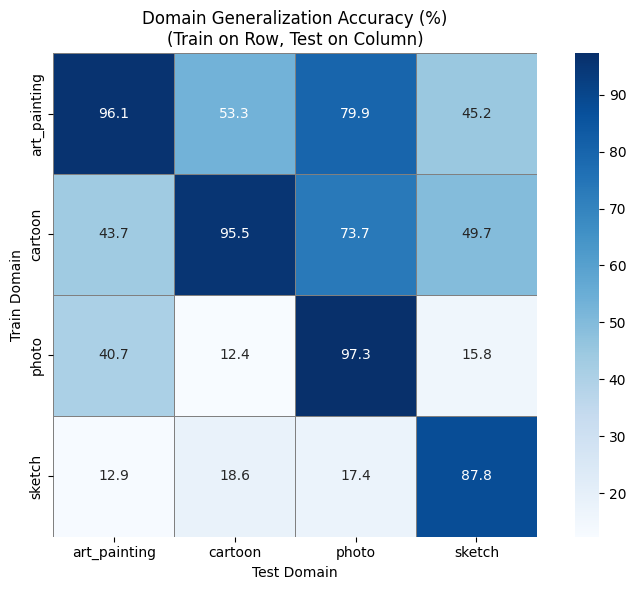

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for heatmap
domains = sorted(results.keys())
data = []

for train_domain in domains:
    row = []
    for test_domain in domains:
        row.append(results[train_domain][test_domain])
    data.append(row)

# Create DataFrame
df = pd.DataFrame(data, index=domains, columns=domains)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".1f", cmap="Blues", cbar=True,
            linewidths=0.5, linecolor='gray', square=True)

plt.title("Domain Generalization Accuracy (%)\n(Train on Row, Test on Column)")
plt.xlabel("Test Domain")
plt.ylabel("Train Domain")
plt.tight_layout()
plt.show()


Part2_SubPart1_3

In [10]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define domains
all_domains = ['art_painting', 'cartoon', 'photo', 'sketch']
data_root = './kfold'

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Load datasets
def load_domain(domain, transform):
    path = os.path.join(data_root, domain)
    return datasets.ImageFolder(path, transform=transform)

# Model with MLP
def get_model():
    model = models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

# Train function
def train(model, loader, criterion, optimizer, epochs=4):
    model.train()
    for epoch in range(epochs):
        loop = tqdm(loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            loop.set_postfix(loss=loss.item())

# Eval function
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

# Leave-one-domain-out experiment
results = {}

for test_domain in all_domains:
    print(f"\n Testing on domain: {test_domain}")
    # Load training domains
    train_domains = [d for d in all_domains if d != test_domain]
    train_datasets = [load_domain(d, transform) for d in train_domains]
    train_dataset = ConcatDataset(train_datasets)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

    # Load test domain
    test_dataset = load_domain(test_domain, transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    # Init model
    model = get_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)

    # Train
    train(model, train_loader, criterion, optimizer, epochs=4)

    # Test
    acc = evaluate(model, test_loader)
    results[test_domain] = acc
    print(f" Accuracy on {test_domain}: {acc:.2f}%")

# Final results
print("\n Final Domain Generalization Results:")
for domain, acc in results.items():
    print(f"Test on {domain:14s} → Accuracy: {acc:.2f}%")


Using device: cuda

 Testing on domain: art_painting


Epoch [4/4]: 100%|██████████| 249/249 [00:30<00:00,  8.18it/s, loss=0.563]


 Accuracy on art_painting: 56.59%

 Testing on domain: cartoon


Epoch [4/4]: 100%|██████████| 239/239 [00:29<00:00,  8.00it/s, loss=0.452]


 Accuracy on cartoon: 57.85%

 Testing on domain: photo


Epoch [4/4]: 100%|██████████| 261/261 [00:31<00:00,  8.26it/s, loss=2.15] 


 Accuracy on photo: 87.96%

 Testing on domain: sketch


Epoch [4/4]: 100%|██████████| 190/190 [00:25<00:00,  7.38it/s, loss=0.48] 


 Accuracy on sketch: 39.17%

 Final Domain Generalization Results:
Test on art_painting   → Accuracy: 56.59%
Test on cartoon        → Accuracy: 57.85%
Test on photo          → Accuracy: 87.96%
Test on sketch         → Accuracy: 39.17%


Part2_SubPart1_4

 Device: cuda

 Running experiment: No Augmentation

 Testing on: art_painting


Epoch [4/4]: 100%|██████████| 249/249 [00:31<00:00,  8.01it/s, loss=0.477]


 Accuracy on art_painting: 63.96%

 Testing on: cartoon


Epoch [4/4]: 100%|██████████| 239/239 [00:29<00:00,  7.99it/s, loss=0.742]


 Accuracy on cartoon: 59.17%

 Testing on: photo


...

 Accuracy on cartoon: 44.41%

 Testing on: photo


Epoch [4/4]: 100%|██████████| 261/261 [00:31<00:00,  8.22it/s, loss=2.89] 


 Accuracy on photo: 87.13%

 Testing on: sketch


Epoch [4/4]: 100%|██████████| 190/190 [00:25<00:00,  7.34it/s, loss=0.83] 


 Accuracy on sketch: 43.85%


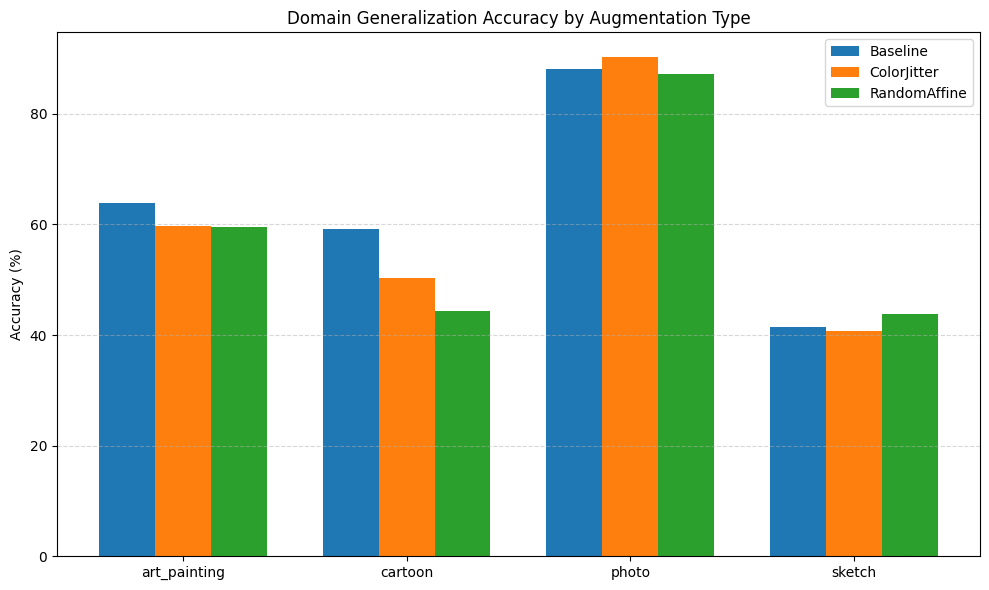

In [11]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Device:", device)

all_domains = ['art_painting', 'cartoon', 'photo', 'sketch']
data_root = './kfold'

# ---------------------------
# Define Transform Variants
# ---------------------------

base_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

color_jitter_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

random_affine_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ---------------------------
# Dataset and Model Functions
# ---------------------------

def load_domain(domain, transform):
    return datasets.ImageFolder(os.path.join(data_root, domain), transform=transform)

def get_model():
    model = models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

def train(model, loader, criterion, optimizer, epochs=4):
    model.train()
    for epoch in range(epochs):
        loop = tqdm(loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            loop.set_postfix(loss=loss.item())

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

# ---------------------------
# Experiment Loop
# ---------------------------

def run_experiment(name, transform):
    print(f"\n Running experiment: {name}")
    results = {}
    for test_domain in all_domains:
        print(f"\n Testing on: {test_domain}")
        train_domains = [d for d in all_domains if d != test_domain]
        train_datasets = [load_domain(d, transform) for d in train_domains]
        train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

        test_dataset = load_domain(test_domain, test_transform)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

        model = get_model()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)

        train(model, train_loader, criterion, optimizer, epochs=4)
        acc = evaluate(model, test_loader)
        results[test_domain] = acc
        print(f" Accuracy on {test_domain}: {acc:.2f}%")
    return results

# Run all experiments
results_baseline = run_experiment("No Augmentation", base_transform)
results_jitter = run_experiment("ColorJitter", color_jitter_transform)
results_affine = run_experiment("RandomAffine", random_affine_transform)

# ---------------------------
# Plotting the Results
# ---------------------------

import numpy as np

labels = all_domains
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, [results_baseline[d] for d in labels], width, label='Baseline')
ax.bar(x, [results_jitter[d] for d in labels], width, label='ColorJitter')
ax.bar(x + width, [results_affine[d] for d in labels], width, label='RandomAffine')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Domain Generalization Accuracy by Augmentation Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Part4_SubPart1_1

In [20]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
import numpy as np
import random

# -------------------------------
#  1. Set All Random Seeds
# -------------------------------
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Device:", device)

# -------------------------------
#  2. Data Loading
# -------------------------------
data_root = './kfold'
train_domains = ['art_painting', 'cartoon', 'photo']
test_domain = 'sketch'

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_datasets = [datasets.ImageFolder(os.path.join(data_root, d), transform=train_transform) for d in train_domains]
test_dataset = datasets.ImageFolder(os.path.join(data_root, test_domain), transform=train_transform)

train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# -------------------------------
#  3. Gradient Reversal Layer
# -------------------------------
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None

class GRL(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversal.apply(x, self.lambda_)

# -------------------------------
#  4. DANN Architecture
# -------------------------------
class DANN(nn.Module):
    def __init__(self, num_classes=7, lambda_=1.0):
        super().__init__()
        self.feature_extractor = models.resnet18(pretrained=True)
        self.feature_extractor.fc = nn.Identity()  # remove the classification head

        self.class_classifier = nn.Sequential(
            nn.Linear(512, 100),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(100, num_classes)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(512, 100),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(100, len(train_domains))  # 3 source domains
        )

        self.grl = GRL(lambda_)

    def forward(self, x):
        features = self.feature_extractor(x)
        class_output = self.class_classifier(features)
        domain_output = self.domain_classifier(self.grl(features))
        return class_output, domain_output

# -------------------------------
#  5. Evaluate Before Training
# -------------------------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            class_outputs, _ = model(imgs)
            _, preds = torch.max(class_outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# -------------------------------
#  6. Training Loop (4 epochs)
# -------------------------------
def train(model, loader, optimizer, ce_loss, lambda_=0.5, epochs=4):
    model.train()
    for epoch in range(epochs):
        print(f" Epoch [{epoch+1}/{epochs}]")
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            domain_labels = torch.randint(0, len(train_domains), (labels.size(0),)).to(device)

            optimizer.zero_grad()
            class_output, domain_output = model(imgs)
            loss_class = ce_loss(class_output, labels)
            loss_domain = ce_loss(domain_output, domain_labels)
            loss = loss_class + lambda_ * loss_domain
            loss.backward()
            optimizer.step()

# -------------------------------
#  Run It All
# -------------------------------
model = DANN(num_classes=7, lambda_=1.0).to(device)
ce_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("\n Accuracy on test (sketch) BEFORE training:")
acc_before = evaluate(model, test_loader)
print(f" Accuracy before: {acc_before:.2f}%")

train(model, train_loader, optimizer, ce_loss, lambda_=1.0, epochs=4)

print("\n Accuracy on test (sketch) AFTER training:")
acc_after = evaluate(model, test_loader)
print(f" Accuracy after: {acc_after:.2f}%")


 Device: cuda


C:\Users\Lenovo\AppData\Roaming\Python\Python39\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python39\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



 Accuracy on test (sketch) BEFORE training:
 Accuracy before: 19.95%
 Epoch [1/4]
 Epoch [2/4]
 Epoch [3/4]
 Epoch [4/4]

 Accuracy on test (sketch) AFTER training:
 Accuracy after: 63.02%


In [21]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def extract_features(model, loader, label_name):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            feats = model.feature_extractor(imgs)
            features.append(feats.cpu())
            labels += [label_name] * imgs.size(0)
    return torch.cat(features, dim=0), labels

def visualize_tsne(model, train_loader, test_loader):
    print("\n Extracting features for t-SNE...")
    train_feats, train_labels = extract_features(model, train_loader, 'Train')
    test_feats, test_labels = extract_features(model, test_loader, 'Test')

    all_features = torch.cat([train_feats, test_feats], dim=0)
    all_labels = train_labels + test_labels

    tsne = TSNE(n_components=2, random_state=42)
    reduced_feats = tsne.fit_transform(all_features.numpy())

    colors = {'Train': 'blue', 'Test': 'red'}
    plt.figure(figsize=(10, 6))
    for label in set(all_labels):
        idxs = [i for i, l in enumerate(all_labels) if l == label]
        plt.scatter(reduced_feats[idxs, 0], reduced_feats[idxs, 1], 
                    label=label, alpha=0.6, color=colors[label])
    
    plt.title("t-SNE Visualization of Features")
    plt.legend()
    plt.grid(True)
    plt.show()


 Device: cuda

 Accuracy on test (sketch) BEFORE training:
 Accuracy before: 19.95%

 Extracting features for t-SNE...


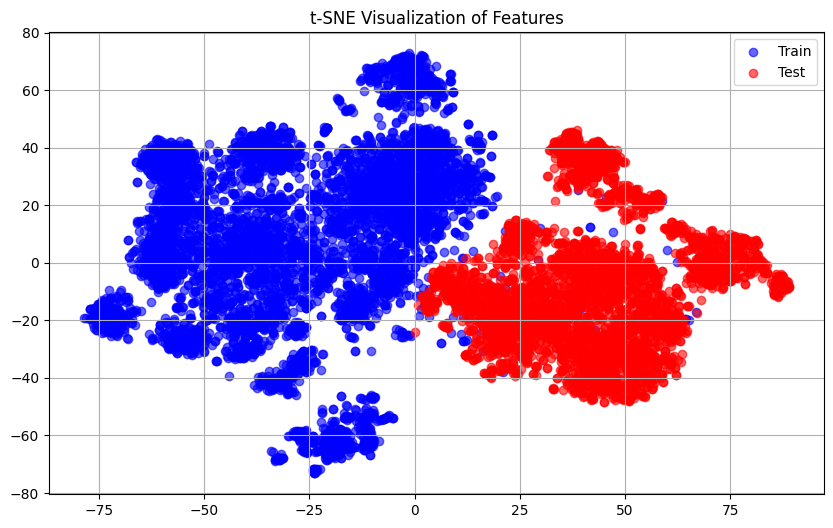


 Epoch [1/4]
 Train Loss: 1.8618 |  Train Accuracy: 79.12%
 Test Loss: 1.0825 |  Test Accuracy: 61.19%

 Epoch [2/4]
 Train Loss: 1.3003 |  Train Accuracy: 95.20%
 Test Loss: 1.0242 |  Test Accuracy: 63.93%

 Epoch [3/4]
 Train Loss: 1.1879 |  Train Accuracy: 98.19%
 Test Loss: 1.1213 |  Test Accuracy: 65.46%

 Epoch [4/4]
 Train Loss: 1.1529 |  Train Accuracy: 98.98%
 Test Loss: 1.1995 |  Test Accuracy: 59.20%

 Accuracy on test (sketch) AFTER training:
 Accuracy after: 59.20%

 Extracting features for t-SNE...


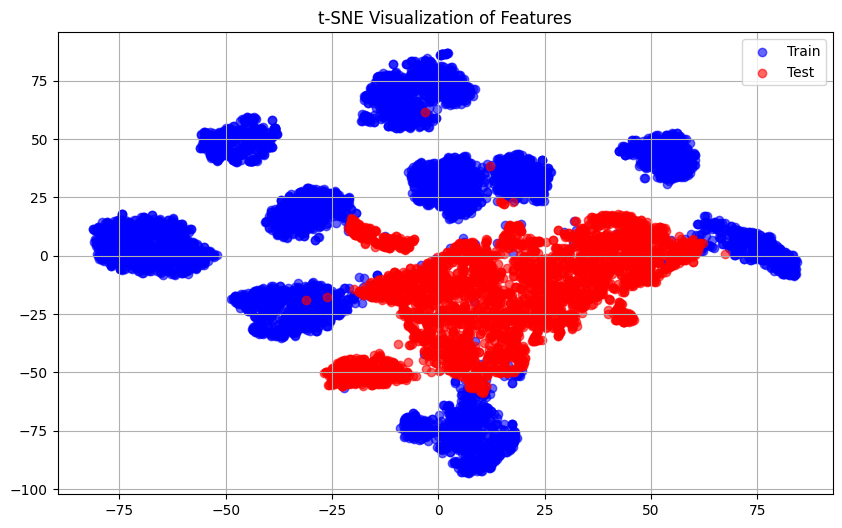

In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
import numpy as np
import random

# -------------------------------
#  1. Set All Random Seeds
# -------------------------------
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Device:", device)

# -------------------------------
#  2. Data Loading
# -------------------------------
data_root = './kfold'
train_domains = ['art_painting', 'cartoon', 'photo']
test_domain = 'sketch'

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_datasets = [datasets.ImageFolder(os.path.join(data_root, d), transform=train_transform) for d in train_domains]
test_dataset = datasets.ImageFolder(os.path.join(data_root, test_domain), transform=train_transform)

train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# -------------------------------
#  3. Gradient Reversal Layer
# -------------------------------
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None

class GRL(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversal.apply(x, self.lambda_)

# -------------------------------
#  4. DANN Architecture
# -------------------------------
class DANN(nn.Module):
    def __init__(self, num_classes=7, lambda_=1.0):
        super().__init__()
        self.feature_extractor = models.resnet18(pretrained=True)
        self.feature_extractor.fc = nn.Identity()  # remove the classification head

        self.class_classifier = nn.Sequential(
            nn.Linear(512, 100),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(100, num_classes)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(512, 100),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(100, len(train_domains))  # 3 source domains
        )

        self.grl = GRL(lambda_)

    def forward(self, x):
        features = self.feature_extractor(x)
        class_output = self.class_classifier(features)
        domain_output = self.domain_classifier(self.grl(features))
        return class_output, domain_output

# -------------------------------
#  5. Evaluation Functions
# -------------------------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            class_outputs, _ = model(imgs)
            _, preds = torch.max(class_outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def evaluate_with_loss(model, loader, loss_fn):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            class_outputs, _ = model(imgs)
            loss = loss_fn(class_outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(class_outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return accuracy, avg_loss

# -------------------------------
#  6. Training Loop (4 epochs)
# -------------------------------
def train(model, loader, optimizer, ce_loss, lambda_=0.5, epochs=4):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        print(f"\n Epoch [{epoch+1}/{epochs}]")

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            domain_labels = torch.randint(0, len(train_domains), (labels.size(0),)).to(device)

            optimizer.zero_grad()
            class_output, domain_output = model(imgs)

            loss_class = ce_loss(class_output, labels)
            loss_domain = ce_loss(domain_output, domain_labels)
            loss = loss_class + lambda_ * loss_domain

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(class_output, 1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        avg_train_loss = total_loss / total_samples
        train_accuracy = 100 * total_correct / total_samples
        print(f" Train Loss: {avg_train_loss:.4f} |  Train Accuracy: {train_accuracy:.2f}%")

        test_accuracy, test_loss = evaluate_with_loss(model, test_loader, ce_loss)
        print(f" Test Loss: {test_loss:.4f} |  Test Accuracy: {test_accuracy:.2f}%")

# -------------------------------
#  Run It All
# -------------------------------

model = DANN(num_classes=7, lambda_=1.0).to(device)
ce_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("\n Accuracy on test (sketch) BEFORE training:")
acc_before = evaluate(model, test_loader)
print(f" Accuracy before: {acc_before:.2f}%")

#  t-SNE before training
visualize_tsne(model, train_loader, test_loader)

#  Train the model
train(model, train_loader, optimizer, ce_loss, lambda_=1.0, epochs=4)

print("\n Accuracy on test (sketch) AFTER training:")
acc_after = evaluate(model, test_loader)
print(f" Accuracy after: {acc_after:.2f}%")

#  t-SNE after training
visualize_tsne(model, train_loader, test_loader)


In [23]:
def extract_features_by_class(model, loader):
    model.eval()
    features = []
    class_labels = []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            feats = model.feature_extractor(imgs)
            features.append(feats.cpu())
            class_labels += lbls.cpu().tolist()
    return torch.cat(features, dim=0), class_labels


In [24]:
import seaborn as sns

def visualize_tsne_by_class(model, loader, title="t-SNE by Class"):
    print(f"\n Extracting class-wise features for: {title}")
    features, class_labels = extract_features_by_class(model, loader)

    tsne = TSNE(n_components=2, random_state=42)
    reduced_feats = tsne.fit_transform(features.numpy())

    plt.figure(figsize=(10, 6))
    palette = sns.color_palette("hls", len(set(class_labels)))
    for cls in set(class_labels):
        idxs = [i for i, label in enumerate(class_labels) if label == cls]
        plt.scatter(reduced_feats[idxs, 0], reduced_feats[idxs, 1], 
                    label=f"Class {cls}", alpha=0.6, color=palette[cls])

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()



 Extracting class-wise features for: t-SNE (Train) by Class


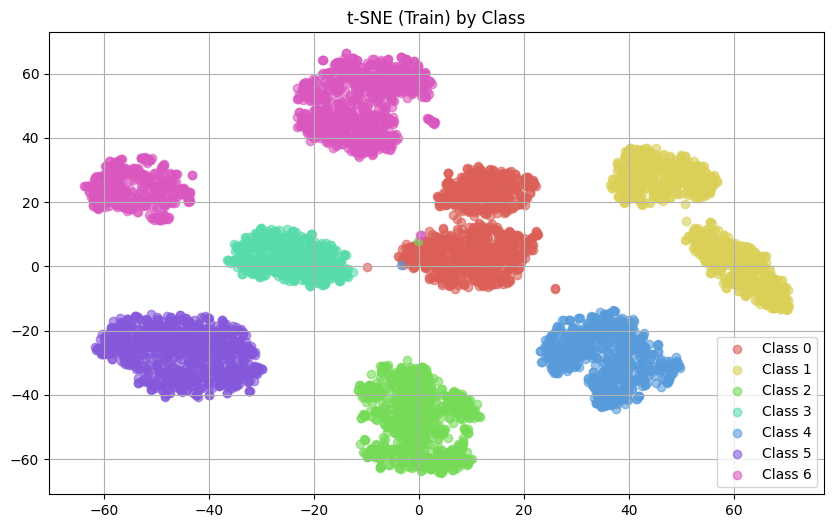


 Extracting class-wise features for: t-SNE (Test) by Class


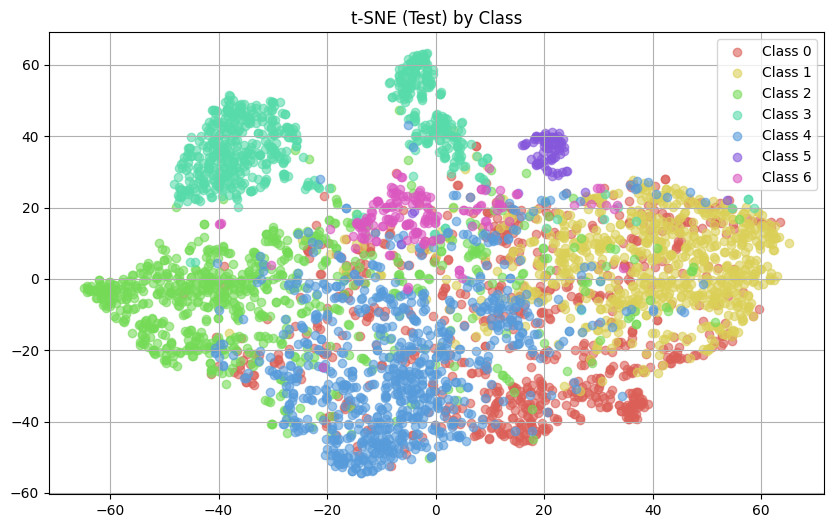

In [26]:
visualize_tsne_by_class(model, train_loader, title="t-SNE (Train) by Class")
visualize_tsne_by_class(model, test_loader, title="t-SNE (Test) by Class")